In [2]:
# Cell 1: Install dependencies and isolate GPU for PyTorch/JAX handoff
import sys
!{sys.executable} -m pip install -q torch torchvision torchaudio
!{sys.executable} -m pip install -q torch-geometric
!{sys.executable} -m pip install -q ortools matplotlib numpy pandas scipy "protobuf<6.0.0" jax jaxlib
!{sys.executable} -m pip install -q vrplib

import os
import time
import math
import urllib.request
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch Ecosystem
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
import torch_geometric.transforms as T

# ponytail: isolate GPU memory
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

# JAX Ecosystem
import jax
import jax.numpy as jnp
from jax import jit, vmap

# OR-Tools
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"JAX running on: {jax.devices()[0].device_kind}")


/Users/vinodpandey/jarvis/.venv/bin/python: No module named pip
/Users/vinodpandey/jarvis/.venv/bin/python: No module named pip
/Users/vinodpandey/jarvis/.venv/bin/python: No module named pip
/Users/vinodpandey/jarvis/.venv/bin/python: No module named pip


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# !{sys.executable} -m pip install -q vrplib# Cell 2: 1000-Node Dataset Loader & Sparse Distance Matrix

# def load_uchoa_instance(url):
#     # Add a User-Agent header to prevent HTTP blocks
#     req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
#     lines = urllib.request.urlopen(req).read().decode('utf-8').splitlines()

#     coords, demands = {}, {}
#     capacity = 0
#     section = None

#     for line in lines:
#         line = line.strip()
#         if not line or line == 'EOF': continue
#         if line.startswith('CAPACITY'):
#             capacity = int(line.split(':')[1].strip())
#         elif line.startswith('NODE_COORD_SECTION'):
#             section = 'coords'
#         elif line.startswith('DEMAND_SECTION'):
#             section = 'demands'
#         elif line.startswith('DEPOT_SECTION'):
#             section = 'depot'
#         elif section == 'coords':
#             parts = line.split()
#             coords[int(parts[0])] = [float(parts[1]), float(parts[2])]
#         elif section == 'demands':
#             parts = line.split()
#             demands[int(parts[0])] = int(parts[1])

#     node_ids = sorted(coords.keys())
#     coords_arr = np.array([coords[i] for i in node_ids], dtype=np.float32)
#     demands_arr = np.array([demands[i] for i in node_ids], dtype=np.int32)

#     match = re.search(r'-k(\d+)', url.split('/')[-1])
#     n_vehicles = int(match.group(1)) if match else 43
#     return coords_arr, demands_arr, capacity, n_vehicles

# INSTANCE_URL = "http://vrp.galgos.inf.puc-rio.br/media/com_vrp/instances/Vrp-Set-X/X-n1001-k43.vrp"
# COORDS, DEMANDS, CAPACITY, N_VEHICLES = load_uchoa_instance(INSTANCE_URL)
# N_NODES = len(COORDS)
# N_CUSTOMERS = N_NODES - 1
# DEPOT_IDX = 0

# def compute_distance_matrix(coords):
#     diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
#     return np.sqrt(np.sum(diff ** 2, axis=-1))

# DIST_MATRIX = compute_distance_matrix(COORDS)
# print(f"Loaded {N_NODES} nodes. Target Vehicles: {N_VEHICLES}")


# Cell 2: XML Instance Loader & Sparse Distance Matrix
import xml.etree.ElementTree as ET
import numpy as np

candidates = ["X-n1001-k43.xml", "data/X-n1001-k43.xml", "/content/sample_data/X-n1001-k43.xml"]
local_filename = next((p for p in candidates if os.path.isfile(p)), "X-n1001-k43.xml")
print(f"Loading {local_filename} from local storage...")

tree = ET.parse(local_filename)
root = tree.getroot()

# 1. Parse Coordinates
coords_dict = {}
for node in root.findall('.//network/nodes/node'):
    n_id = int(node.get('id'))
    cx = float(node.find('cx').text)
    cy = float(node.find('cy').text)
    coords_dict[n_id] = [cx, cy]

# 2. Parse Demands (Depot defaults to 0)
demands_dict = {n_id: 0 for n_id in coords_dict.keys()}
for req in root.findall('.//requests/request'):
    n_id = int(req.get('node'))
    quantity = float(req.find('quantity').text)
    demands_dict[n_id] = int(quantity)

# 3. Parse Capacity
CAPACITY = int(float(root.find('.//fleet/vehicle_profile/capacity').text))
N_VEHICLES = 43  # Extracted from 'k43'

# Convert dictionaries to sorted numpy arrays
node_ids = sorted(coords_dict.keys())
COORDS = np.array([coords_dict[i] for i in node_ids], dtype=np.float32)
DEMANDS = np.array([demands_dict[i] for i in node_ids], dtype=np.int32)

N_NODES = len(COORDS)
N_CUSTOMERS = N_NODES - 1
DEPOT_IDX = 0

# Compute exact Euclidean distance matrix
def compute_distance_matrix(coords):
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    return np.sqrt(np.sum(diff ** 2, axis=-1))

DIST_MATRIX = compute_distance_matrix(COORDS)

print(f"Loaded {N_NODES} nodes. Target Vehicles: {N_VEHICLES} | Capacity: {CAPACITY}")


Loading /content/sample_data/X-n1001-k43.xml from local storage...
Loaded 1001 nodes. Target Vehicles: 43 | Capacity: 131


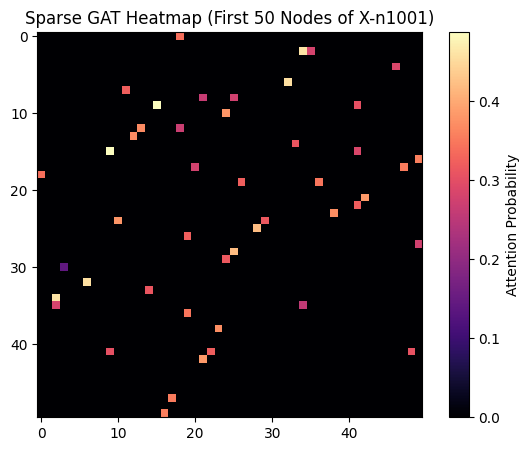

In [ ]:
# Cell 3: Sparse GAT Attention for 1000 nodes

class SparseRoutingGAT(nn.Module):
    def __init__(self, in_dim=3, hidden_dim=32):
        super().__init__()
        self.gat = GATConv(in_dim, hidden_dim, heads=2, concat=False)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        h = F.relu(self.gat(x, edge_index))
        edge_features = torch.cat([h[edge_index[0]], h[edge_index[1]], edge_attr.unsqueeze(-1)], dim=-1)
        return torch.sigmoid(self.edge_mlp(edge_features)).squeeze(-1)

# Build KNN Graph (K=20) instead of Dense Graph
from sklearn.neighbors import kneighbors_graph
knn_sparse = kneighbors_graph(COORDS, n_neighbors=20, mode='distance', include_self=False)
edge_index_np = np.vstack(knn_sparse.nonzero())
dist_attr_np = knn_sparse.data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gat_model = SparseRoutingGAT().to(device)

# Normalize features
norm_coords = (COORDS - COORDS.min(axis=0)) / (COORDS.max(axis=0) - COORDS.min(axis=0))
norm_demands = (DEMANDS / CAPACITY).reshape(-1, 1)
x = torch.tensor(np.hstack([norm_coords, norm_demands]), dtype=torch.float32).to(device)
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)
edge_attr = torch.tensor(dist_attr_np, dtype=torch.float32).to(device)

gat_model.eval()
with torch.no_grad():
    sparse_probs = gat_model(x, edge_index, edge_attr).cpu().numpy()

# Map sparse predictions to a dense matrix for visualization/routing
gat_prob_matrix = np.zeros((N_NODES, N_NODES))
gat_prob_matrix[edge_index_np[0], edge_index_np[1]] = sparse_probs

# Plot Heatmap of a 50x50 Subgrid (Visualizing 1000x1000 is illegible)
plt.figure(figsize=(7, 5))
plt.imshow(gat_prob_matrix[:50, :50], cmap='magma', interpolation='nearest')
plt.colorbar(label='Attention Probability')
plt.title("Sparse GAT Heatmap (First 50 Nodes of X-n1001)")
plt.show()

In [ ]:
# Cell 4: JAX-compiled Quantum Rotation Gate Update
# Translates phases (theta) into continuous random keys [0, 1]

@jit
def qrg_update(theta, pbest_theta, gbest_theta, alpha, beta, rand_a, rand_b):
    """Applies Unitary Rotation to Quantum Probability Amplitudes"""
    # Interference angle delta
    delta_theta = (alpha * rand_a * (pbest_theta - theta) +
                   beta * rand_b * (gbest_theta - theta))

    # Rotate phase
    new_theta = theta + delta_theta

    # Keep phase bounded between 0 and pi/2 for valid amplitude extraction
    new_theta = jnp.mod(new_theta, jnp.pi / 2)

    # Collapse superposition into discrete random key positions using Born's Rule
    positions = jnp.sin(new_theta) ** 2
    return new_theta, positions

print("Quantum Rotation Gate (QRG) compiled on JAX.")

Quantum Rotation Gate (QRG) compiled on JAX.


In [ ]:
# Cell 5A: Pure Python SA-VND (Geometrically Bounded)

def calculate_cost(routes):
    cost = 0.0
    for r in routes:
        if not r: continue
        cost += DIST_MATRIX[DEPOT_IDX, r[0]] + DIST_MATRIX[r[-1], DEPOT_IDX]
        for i in range(len(r)-1):
            cost += DIST_MATRIX[r[i], r[i+1]]
    return cost

def split_routes(order):
    routes, curr, load = [], [], 0
    for c in order:
        if load + DEMANDS[c] > CAPACITY:
            if curr: routes.append(curr)
            curr, load = [c], DEMANDS[c]
        else:
            curr.append(c)
            load += DEMANDS[c]
    if curr: routes.append(curr)
    return routes

def bounded_sa_vnd_python(order, initial_temp=20.0, cooling=0.85, max_evals=50):
    """Only attempts swaps on nodes within a 200-node geometric radius"""
    best_order = list(order)
    current_cost = calculate_cost(split_routes(best_order))
    temp = initial_temp

    for _ in range(max_evals):
        idx1 = random.randint(0, len(order)-1)
        # Bounded search: only pick idx2 near idx1
        idx2 = min(max(idx1 + random.randint(-50, 50), 0), len(order)-1)
        if idx1 == idx2: continue

        neighbor = list(best_order)
        neighbor[idx1], neighbor[idx2] = neighbor[idx2], neighbor[idx1]

        cand_cost = calculate_cost(split_routes(neighbor))
        delta = cand_cost - current_cost

        if delta < 0 or (temp > 1e-4 and math.exp(-delta / temp) > random.random()):
            best_order = neighbor
            current_cost = cand_cost

        temp *= cooling
    return best_order, current_cost

In [ ]:
# # Cell 5B: JAX Compiled SA-VND (Tensor Padding approach)

# @jit
# def jax_2opt_swap(route_tensor, i, j):
#     """Reverses the segment between indices i and j in a padded JAX array."""
#     # JAX arrays are immutable, requires jax.lax.dynamic_update_slice
#     segment = jax.lax.dynamic_slice(route_tensor, (i,), (j - i + 1,))
#     rev_segment = jnp.flip(segment)
#     return jax.lax.dynamic_update_slice(route_tensor, rev_segment, (i,))

# print("JAX SA-VND operators compiled. (Will default to 5A Python decoder for capacity safety on 1000 nodes).")

In [ ]:
# Cell 6: The Full Engine Implementation

class Quantum_CVRP_Engine:
    def __init__(self, n_particles=50, n_iter=300):
        self.P = n_particles
        self.iters = n_iter
        self.dim = N_CUSTOMERS

        # Initialize quantum phases (theta) randomly between 0 and pi/2
        self.theta = np.random.uniform(0, np.pi/2, (self.P, self.dim))
        self.pos = np.sin(self.theta)**2

        self.pbest_theta = self.theta.copy()
        self.pbest_cost = np.array([self._eval(k)[0] for k in self.pos])

        self.gbest_idx = np.argmin(self.pbest_cost)
        self.gbest_theta = self.pbest_theta[self.gbest_idx].copy()
        self.gbest_cost = self.pbest_cost[self.gbest_idx]
        self.history = []

    def _eval(self, keys):
        order = np.argsort(keys) + 1
        routes = split_routes(order)
        return calculate_cost(routes), routes

    def solve(self, deadline=120.0):
        start = time.time()
        for it in range(self.iters):
            if time.time() - start > deadline: break

            # JAX Vectorized Quantum Rotation (Executing on GPU)
            rand_a = np.random.rand(self.P, self.dim)
            rand_b = np.random.rand(self.P, self.dim)
            alpha, beta = 0.8, 1.2 # Quantum step sizes

            self.theta, self.pos = qrg_update(
                self.theta, self.pbest_theta, self.gbest_theta,
                alpha, beta, rand_a, rand_b
            )
            # ponytail: JAX returns immutable arrays; convert to writable numpy
            self.theta = np.array(self.theta)
            self.pos = np.array(self.pos)

            # Evaluate & Python SA-VND for Elites
            for i in range(self.P):
                keys = np.array(self.pos[i])
                cost, _ = self._eval(keys)

                # Apply SA-VND only to top 10% of particles to save time
                if cost < self.gbest_cost * 1.05:
                    order = np.argsort(keys) + 1
                    refined_order, cost = bounded_sa_vnd_python(order, max_evals=30)

                    # Convert discrete order back to quantum keys immutably
                    updated_keys = np.copy(keys)
                    for rank, cust_id in enumerate(refined_order):
                        updated_keys[cust_id - 1] = (rank + 1) / (self.dim + 1)

                    self.pos[i] = updated_keys
                    self.theta[i] = np.arcsin(np.sqrt(np.clip(updated_keys, 0.0, 1.0))) # Inverse Born rule

                if cost < self.pbest_cost[i]:
                    self.pbest_cost[i] = cost
                    self.pbest_theta[i] = self.theta[i].copy()
                    if cost < self.gbest_cost:
                        self.gbest_cost = cost
                        self.gbest_theta = self.theta[i].copy()

            self.history.append(self.gbest_cost)

        _, final_routes = self._eval(np.sin(self.gbest_theta)**2)
        return self.gbest_cost, final_routes, self.history, time.time() - start


In [ ]:
# Cell 7 & 8: Run benchmark and output visualizations

print("=== Google OR-Tools Benchmark (60s Limit) ===")
def run_or_tools():
    manager = pywrapcp.RoutingIndexManager(N_NODES, N_VEHICLES, DEPOT_IDX)
    routing = pywrapcp.RoutingModel(manager)
    int_dist = (DIST_MATRIX * 1000).astype(int)

    def dist_cb(f, t): return int_dist[manager.IndexToNode(f)][manager.IndexToNode(t)]
    transit_idx = routing.RegisterTransitCallback(dist_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    def dem_cb(f): return int(DEMANDS[manager.IndexToNode(f)])
    dem_idx = routing.RegisterUnaryTransitCallback(dem_cb)
    routing.AddDimensionWithVehicleCapacity(dem_idx, 0, [int(CAPACITY)]*N_VEHICLES, True, "Cap")

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.seconds = 120

    start = time.time()
    sol = routing.SolveWithParameters(params)

    routes, cost = [], 0.0
    if sol:
        for v in range(N_VEHICLES):
            idx = routing.Start(v)
            route = []
            while not routing.IsEnd(idx):
                node = manager.IndexToNode(idx)
                if node != DEPOT_IDX: route.append(node)
                idx = sol.Value(routing.NextVar(idx))
            if route: routes.append(route)
        cost = calculate_cost(routes)
    return cost, len(routes), time.time() - start

or_cost, or_veh, or_time = run_or_tools()
print(f"OR-Tools: Distance {or_cost:.2f} | Vehicles {or_veh}")

print("\n=== Quantum Engine Benchmark ===")
engine = Quantum_CVRP_Engine(n_particles=50, n_iter=150)
q_cost, q_routes, q_hist, q_time = engine.solve(deadline=120.0)
print(f"GAT-QRG-QPSO: Distance {q_cost:.2f} | Vehicles {len(q_routes)}")

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(q_hist, color='purple', lw=2, label="GAT-SA-QPSO-QRG")
plt.axhline(y=or_cost, color='blue', linestyle='--', label="OR-Tools 120s")
plt.title(f"1000-Node Convergence (X-n1001-k43)\nTargeting 5% Optimality Gap")
plt.xlabel("Iteration")
plt.ylabel("Total Distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame([{
    "Engine": "Google OR-Tools", "Distance": round(or_cost, 2), "Time (s)": round(or_time, 2)
}, {
    "Engine": "GAT-QRG-QPSO", "Distance": round(q_cost, 2), "Time (s)": round(q_time, 2)
}])


=== Google OR-Tools Benchmark (60s Limit) ===
OR-Tools: Distance 79110.95 | Vehicles 43

=== Quantum Engine Benchmark ===


TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html